In [4]:
using LinearAlgebra
using OMEinsum

# TODO Fix figures

# MPS states and their properties
We start by expliclty constucting  Matrix product states (MPS)  

\begin{equation}
c_{i_0,i_1\cdots i_{N-2},i_{N-1}} = \textrm{tTr}\left(A^{i_1}A^{i_2}\cdots A^{i_{N-2}}A^{i_{N-1}}\right)
\end{equation} 

today we will study some of their properties and see how they help computing things. 


In what follows, we will use the following ordering convention for MPS indices: [virtual left, physical, virtual right]

Let's start by trying to obtain a MPS for the random states we generated in last tutorials follwing the recipe that we have seen in books that is by performing iterated SVDs, 

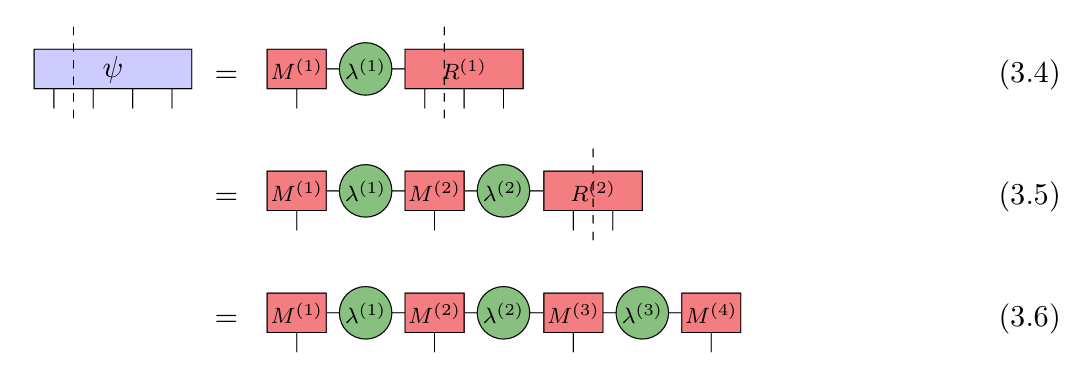
from doi:10.1088/1751-8121/aa6dc3



In [5]:
# We can generate a random state by starting from a product state and applying some random unitary to it 
function generate_random_state(N)
    dim_h = 2^N
    init_state = zeros(ComplexF64, dim_h)
    init_state[1] = 1.0      #   This generates the state |↑↑↑...↑>

    random_h = rand(ComplexF64, dim_h, dim_h) 
    random_h = random_h + random_h'     #     This generates a Hermitian random H = A + A^dagger
    random_h = random_h / norm(random_h) * N

    random_unitary = exp(-im * random_h)    #    Creates a Unitary matrix from the Hermitian one
                                            #    (So we do not lose norm) 
    random_state = random_unitary * init_state
    return random_state
end



generate_random_state (generic function with 1 method)

### Obtaining an MPS from a bit vector via QR decompositions 

Here's an example of how a conversion of a state vector to an MPS form could go: we iteratively sweep doing QR decompositions 

In [6]:
function tensor_to_mps_qr(w)
    nspins = Int(log2(length(w)))
    println("nspins = $nspins")

    mps_tensors = []

    # first tensor
    w = reshape(w, (2, 2^(nspins - 1)))
    F = qr(w)
    q = Matrix(F.Q)

    r = F.R
    push!(mps_tensors, q)
    virtual_dim = size(q, 2)
    println("virtual_dim = $virtual_dim")

    for nn in 2:nspins-1
        println("Factorizing $(nn)th tensor")
        r = reshape(r, (virtual_dim * 2, 2^(nspins - nn)))
        F = qr(r)
        q = Matrix(F.Q)
        r = F.R

        push!(mps_tensors, reshape(q, (virtual_dim, 2, size(q, 2))))
        
        virtual_dim = size(q, 2)
        println("virtual_dim = $virtual_dim")
    end

    push!(mps_tensors, reshape(r, (virtual_dim, 2)))

    return mps_tensors
end


tensor_to_mps_qr (generic function with 1 method)

In [7]:
myrand = rand(ComplexF64,1024)
mpstensors = tensor_to_mps_qr(myrand)

nspins = 10
virtual_dim = 2
Factorizing 2th tensor
virtual_dim = 4
Factorizing 3th tensor
virtual_dim = 8
Factorizing 4th tensor
virtual_dim = 16
Factorizing 5th tensor
virtual_dim = 32
Factorizing 6th tensor
virtual_dim = 16
Factorizing 7th tensor
virtual_dim = 8
Factorizing 8th tensor
virtual_dim = 4
Factorizing 9th tensor
virtual_dim = 2


10-element Vector{Any}:
 ComplexF64[-0.14593563901085216 - 0.09190572287728418im -0.18152520157399346 - 0.9681449935636807im; -0.3680472337666696 - 0.9136724583162175im -0.07353610613928607 + 0.15600100552552099im]
 ComplexF64[-0.7757613885847368 + 0.0im -0.39228913931764964 + 0.3116112798153932im; 0.0 + 0.0im -0.38366901027619044 + 0.0im;;; 0.12169041578136715 - 0.3613573497309208im -0.0022453837268808785 + 0.3217870421292303im; -0.6014352776132759 + 0.47565786879028404im 0.017594816288885012 + 0.4034550624442953im;;; -0.34238541082532903 + 0.3357300487376671im -0.16538885299414519 - 0.43215321121901884im; -0.5330019787381188 + 0.02846180421211314im 0.5104030089935083 - 0.10264150690417356im;;; -0.10394807486951935 + 0.10981320067723777im 0.45197375693003283 - 0.4765139574239069im; -0.1942369968704762 + 0.2989916455506856im -0.6389690351718607 - 0.10190479450876325im]
 ComplexF64[-0.6284689589720844 + 0.0im -0.6085277448777722 + 0.07794570160569106im; 0.0 + 0.0im -0.47816860930399196 

In [8]:
# Reconstruct a full state vector by contracting an MPS 
function statevector_from_mps(mps_list)

    # First tensor
    w_rec = mps_list[1]

    for jj in 2:length(mps_list)-1
        println("$(jj-1) - $(size(w_rec)) * $(size(mps_list[jj]))")
        w_rec = ein"ia,ajb->ijb"(w_rec, mps_list[jj])
        w_rec = reshape(w_rec, (size(w_rec,1) * size(w_rec,2), size(w_rec,3)))
    end

    # Final tensor
    w_rec = ein"ia,aj->ij"(w_rec, mps_list[end])
    w_rec = reshape(w_rec, (size(w_rec,1) * size(w_rec,2),))

    return w_rec
end


statevector_from_mps (generic function with 1 method)

In [9]:
wrec = statevector_from_mps(mpstensors);
wrec ≈ myrand

1 - (2, 2) * (2, 2, 4)
2 - (4, 4) * (4, 2, 8)
3 - (8, 8) * (8, 2, 16)
4 - (16, 16) * (16, 2, 32)
5 - (32, 32) * (32, 2, 16)
6 - (64, 16) * (16, 2, 8)
7 - (128, 8) * (8, 2, 4)
8 - (256, 4) * (4, 2, 2)


true

### Factorizing using SVD

We can do somethinng analogous using SVD. While QR decompositions are faster, SVD allows us to compute the entanglement of a state and truncate in a controlled way.

### Playaround 1:
Contruct a function analogous to `tensor_to_mps_qr()` which uses SVD instead to factorize the state. You can call it `tensor_to_mps_svd()` and check that when you reconstruct to a tensor you retain the same results. 

In [24]:
function tensor_to_mps_svd(w)
    nspins = Int(log2(length(w)))
    println("nspins = $nspins")

    mps_tensors = []

    # first tensor
    w = reshape(w, (2, 2^(nspins - 1)))
    F = svd(w)
    q = Matrix(F.U)

    r = diagm(F.S) * (F.Vt)
    push!(mps_tensors, q)
    virtual_dim = size(q, 2)
    println("virtual_dim = $virtual_dim")

    for nn in 2:nspins-1
        println("Factorizing $(nn)th tensor")
        r = reshape(r, (virtual_dim * 2, 2^(nspins - nn)))
        F = svd(r)
        q = Matrix(F.U)
        r = diagm(F.S) * (F.Vt)

        push!(mps_tensors, reshape(q, (virtual_dim, 2, size(q, 2))))
        
        virtual_dim = size(q, 2)
        println("virtual_dim = $virtual_dim")
    end

    push!(mps_tensors, reshape(r, (virtual_dim, 2)))

    return mps_tensors
end

tensor_to_mps_svd (generic function with 1 method)

In [29]:
A = rand(1024);
B = tensor_to_mps_svd(A)
B = statevector_from_mps(B)
A ≈ B

nspins = 10
virtual_dim = 2
Factorizing 2th tensor
virtual_dim = 4
Factorizing 3th tensor
virtual_dim = 8
Factorizing 4th tensor
virtual_dim = 16
Factorizing 5th tensor
virtual_dim = 32
Factorizing 6th tensor
virtual_dim = 16
Factorizing 7th tensor
virtual_dim = 8
Factorizing 8th tensor
virtual_dim = 4
Factorizing 9th tensor
virtual_dim = 2
1 - (2, 2) * (2, 2, 4)
2 - (4, 4) * (4, 2, 8)
3 - (8, 8) * (8, 2, 16)
4 - (16, 16) * (16, 2, 32)
5 - (32, 32) * (32, 2, 16)
6 - (64, 16) * (16, 2, 8)
7 - (128, 8) * (8, 2, 4)
8 - (256, 4) * (4, 2, 2)


true

### Playaround

We can reduce the memory required to save the svd by trucating some of the Schmidt coeficients. Instead of using the `svd()` function from `LinearAlgebra`, we can use the function defined in the previous class. 

Use the function `truncated_svd()` to define a new function `tensor_to_mps_svd_truncated(w;howmany,cutoff)` we can add an additional argument that tells you that you will remove the Schmidt coefficient that do not affect the norm more than the cutoff.

In [ ]:
function truncated_svd(m::AbstractMatrix; howmany::Int = maximum(size(m)), cutoff::Number = 0) 
    # specifying the input types is not necessary, but can help for multiple dispatch 
    F = svd(m)  # F is a SVD struct, contains fields U, S, Vt (and also V if required). We can access them as F.U, F.S and so on 
    aux = 0.
    aux_total = sum(abs.(F.S).^2)
    it = 0
    for i=eachindex(F.S)
        it+=1
        aux += abs.((F.S)[it]).^2
        if sqrt(aux_total-aux)<cutoff
            @show sqrt(aux_total-aux)
            break
        end
    end
    @show it
    cut = min(it, howmany)
    @info "keeping $(cut)/$(length(F.S)) singular values"
    @info "Norm of discarded SV: $(norm(F.S[cut+1:end]))"
    return F.U[:,1:cut], F.S[1:cut], F.Vt[1:cut,:]
end

# You can check that if you do not use the howmany option the cutoff is the upperbound of the norm of 
# the discarded SV values. 
# Recalling the previous lecture, this means that it will also be an upperbound to the difference between the
# real tensor and the reconstructed one.

truncated_svd(rand(20,20); cutoff=1e-1)

#Now modify the function tensor_to_mps_svd() to create tensor_to_mps_svd_truncated()

sqrt(aux_total - aux) = 0.0920962021784697
it = 18


[ Info: keeping 18/20 singular values
[ Info: Norm of discarded SV: 0.09209620217838103


([-0.22838934318888682 -0.10341263207714818 … 0.24277233574882526 -0.05258629936531653; -0.221032651085196 -0.1470641825898514 … -0.1700603840126962 -0.08481885128966897; … ; -0.20769183741928512 -0.1525711554859819 … -0.19852905703140464 -0.3533832406198912; -0.21097324988988495 -0.28811987634469544 … -0.3214301200540566 0.3554381048155419], [9.915781410890647, 2.3259386614607434, 2.1110152007362593, 1.929707797628358, 1.736578777471904, 1.6889084416227664, 1.5688466836778199, 1.4817369274681935, 1.3228637472289733, 1.2328734645714796, 0.9482064558634641, 0.8319835436189668, 0.7683456300494658, 0.7055707653899813, 0.606506630995266, 0.43617958173361643, 0.29525799234652234, 0.10294616275236254], [-0.15958799848935054 -0.22825379793306072 … -0.23317655415088692 -0.24305707527529863; -0.1513555801925513 0.058860592805508 … -0.4031724110401779 0.06607755024761411; … ; 0.17973891247882373 -0.2579695340034064 … -0.1422780768952061 -0.11520417102854122; -0.4601474265608189 -0.20808000824195

# Playing with MPS
Even though in real life we will never have the full state of a quantum many-body system (since it is exponentially hard), we can play a bit with specific examples 

Now let start generating some interesting states and obtain their MPS decomposition. Let's first generate the $W$ state:  
$$ |W  \rangle =\frac{1}{\sqrt{N}}\sum_{n=1}^{N} |0 \cdots 0 1_n 0\cdots 0\rangle  $$

In [10]:
function build_wstate(L=6)
    up = [1, 0]
    down = [0, 1]


    # First one |uddddddddd..> 
    wnn = up
    for jj in 1:(L-1)
        wnn = kron(wnn, down)
    end

    println(size(wnn))

    final_w = wnn

    for up_site in 2:L
        wnn = down
        for jj in 2:L
            if jj == up_site
                wnn = kron(wnn, up)
            else
                wnn = kron(wnn, down)
            end
        end
        final_w += wnn
    end

    wstate = final_w / sqrt(L)
    return wstate
end

wstate = build_wstate(2)
norm(wstate)

(4,)


0.9999999999999999

### Playaround: define the WW state 

$$ |W W \rangle =\frac{1}{\sqrt{N-1}}\sum_{n=1}^{N-1} |0 \cdots 0 1_n 1_{n+1} 0\cdots 0\rangle  $$

In [11]:

# Solution

#########TODO REMOVE SOLUTION ?

function build_wwstate(L)

    @assert L > 1 "WW state not defined for L = 1"
    up = [1, 0]
    down = [0, 1]


    # First one |uddddddddd..> 
    wnn = kron(up,up)
    for jj in 1:(L-2)
        wnn = kron(wnn, down)
    end

    println(size(wnn))

    final_w = wnn

    for up_site in 2:L-1
        wnn = down
        for jj in 2:L-1
            if jj == up_site
                wnn = kron(wnn, kron(up,up))
            else
                wnn = kron(wnn, down)
            end
        end
        final_w += wnn
    end

    wstate = final_w / sqrt(L-1)
    return wstate
end

wwstate = build_wwstate(7)
norm(wwstate)

(128,)


1.0

## WW from state automata 

Now let's build the MPS for the state $WW$ in a more automatic way 


In [12]:
"""
Build |WW> = 1/sqrt(N-1) * sum_{n=1}^{N-1} |0...0 1_n 1_{n+1} 0...0> as an MPS
of N qubits (bond dimension 3).

Each tensor is built as a "matrix of vectors": a Dl x Dr matrix whose
(alpha,beta) entry is a length-2 vector in the physical space. Virtual
indices 1,2,3 mean:
  1 -> no excitation placed yet
  2 -> first 1 of the pair just placed (must place the second 1 next)
  3 -> pair already placed, everything else must be 0
  """

function build_WW_mps(N::Int)
    up = [1, 0]
    dn = [0, 1]

    # bulk tensors 
    mi = zeros(3,2,3)

    # vL,p,vR
    mi[1,:,1] = dn
    mi[1,:,2] = up
    mi[2,:,3] = up
    mi[3,:,3] = dn

    # left and right boundaries 
    mL = mi[1,:,:]
    mR = mi[:,:,3]

    mps_tensors = Vector{AbstractArray}(undef, N)
    mps_tensors[1] = mL
    for jj = 2:N-1
      mps_tensors[jj] = mi 
    end
    mps_tensors[N] = mR /sqrt(N-1)  # we should put the normalization factor somewhere

    println(size.(mps_tensors))
    return mps_tensors
end

ww_mps = build_WW_mps(10)
wwrec = statevector_from_mps(ww_mps)
@show wwrec ≈ build_wwstate(10)

@show norm(wwrec) 



Tuple{Int64, Int64, Vararg{Int64}}[(2, 3), (3, 2, 3), (3, 2, 3), (3, 2, 3), (3, 2, 3), (3, 2, 3), (3, 2, 3), (3, 2, 3), (3, 2, 3), (3, 2)]
1 - (2, 3) * (3, 2, 3)
2 - (4, 3) * (3, 2, 3)
3 - (8, 3) * (3, 2, 3)
4 - (16, 3) * (3, 2, 3)
5 - (32, 3) * (3, 2, 3)
6 - (64, 3) * (3, 2, 3)
7 - (128, 3) * (3, 2, 3)
8 - (256, 3) * (3, 2, 3)
(1024,)
wwrec ≈ build_wwstate(10) = true
norm(wwrec) = 1.0


1.0

### Playaround

Check that if you use the function `tensor_to_mps_svd_truncated()` on `the build_wwstate(L)` with a mild cutoff (or howmany \approx 3) to check that the maximum dimension you get is 3 and the error committed is negligible

# Norm of an MPS 

if we have an MPS, computing norms is easily done. In fact, computing the overlap between two quantum states is easily done:

In [13]:
""" Computes the overlap <bra|ket> between two MPS in a not-too-inefficient way.
    Conjugates the first MPS input (bra) """ 
function mps_overlap(bra, ket)
    # contract the physical leg of the first tensors -> (bra_bond, ket_bond)
    left_env = ein"ia,ib->ab"(conj(bra[1]), ket[1])

    for (Abra, Aket) in zip(bra[2:end-1], ket[2:end-1])
        # absorb the next pair of bulk tensors into the environment
        left_env = ein"ab,ajc,bjd->cd"(left_env, conj(Abra), Aket)
    end

    # close with the last tensors (contract bond + physical legs -> scalar)
    result = ein"ab,aj,bj->"(left_env, conj(bra[end]), ket[end])

    return result[]
end

mps_norm(psi) = sqrt(real(mps_overlap(psi,psi)))


mps_norm (generic function with 1 method)

In [14]:

mps_norm(build_WW_mps(8)) ≈ 1


Tuple{Int64, Int64, Vararg{Int64}}[(2, 3), (3, 2, 3), (3, 2, 3), (3, 2, 3), (3, 2, 3), (3, 2, 3), (3, 2, 3), (3, 2)]


true

In [15]:
# we can also easily build a random MPS. The most naive way could go like this 
""" builds a random un-normalized MPS
    L: Number of constituents desired
    chi: Bond dimension of the MPS
    d: Dimension of the local Hilbert space
""" 
function build_random_mps(L, chi; d=2)

    mps_list = AbstractArray[]
    
    push!(mps_list, rand(ComplexF64, d, chi))

    for jj in 2:L-1
        push!(mps_list, rand(ComplexF64, chi, d, chi))
    end

    push!(mps_list, rand(ComplexF64, chi, d))

    # First crude attempt at normalizing - this does NOT actually normalize the MPS! 
    return [A/norm(A) for A in mps_list]
end

psir = build_random_mps(10, 5)

mps_norm(psir)

0.25710115620447904

## Playaround: expectation value of a local operator with MPS 

Write a function `expval(psi, operator, site)` that computes the expectation value of a given `operator` acting on a given `site` of the MPS `psi`

(It's a one-line modification of the norm function)

# Gauge freedom and canonical forms 

Tensor networks are well defined up to a Gauge transformations. We can add $X$ and $X^{-1}$ in each link and the final result does not change. 

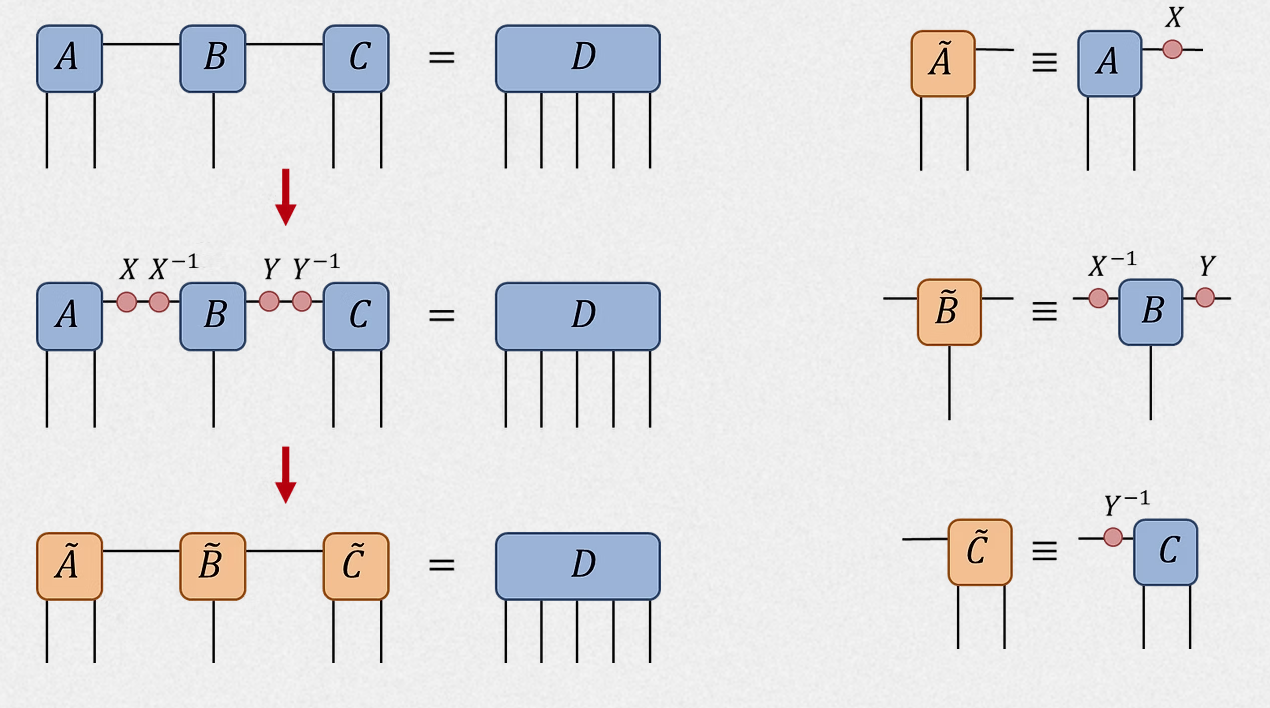
From tensor.net

This is important when truncating an MPS or looking at the Von Neuman Entropy.
Typically there are two gauges that one choose, left- and (right-) canonical form. This corresponds to have only the right (left) tensor which is not unitary.

We can use this to bring any tensor to a "canonical" form. We can 

In [ ]:
function orthogonalize_mps_left!(psi_mps)
    q, r = qr(psi_mps[1])
    psi_mps[1] = Matrix(q)

    for ii in 2:length(psi_mps)-1
        r_m = ein"ij,jkl->ikl"(r, psi_mps[ii])
        println("ii=$ii, size(r_m)=$(size(r_m))") 
        d1, d2, d3 = size(r_m)
        q, r = qr(reshape(r_m, d1*d2, d3))
        q = Matrix(q)
        psi_mps[ii] = reshape(q, d1, d2, size(q, 2))
    end

    psi_mps[end] = ein"ij,jp->ip"(r, psi_mps[end])

    return psi_mps 
end

orthogonalize_mps_left(psi) = orthogonalize_mps_left!(copy(psi))

function is_left_can(psi)
    is_can = Bool[]

    left_env = ein"pv,pw->vw"(psi[1], conj(psi[1]))
    push!(is_can, isapprox(left_env, I(size(left_env, 2))))

    for ii in 2:length(psi)-1
        left_env = ein"lpr,lpk->rk"(psi[ii], conj(psi[ii]))
        push!(is_can, isapprox(left_env, I(size(left_env, 2))))
    end

    return all(is_can)
end


is_left_can (generic function with 1 method)

In [18]:
@show is_left_can(psir)
psir_o = orthogonalize_mps_left(psir)
@show is_left_can(psir_o)
@show mps_overlap(psir, psir_o)/mps_norm(psir)/mps_norm(psir_o)
@show mps_norm(psir)
@show mps_norm(psir_o)
@show norm.(psir)
@show norm.(psir_o)


is_left_can(psir) = false
ii=2, size(r_m)=(2, 2, 5)
ii=3, size(r_m)=(4, 2, 5)
ii=4, size(r_m)=(5, 2, 5)
ii=5, size(r_m)=(5, 2, 5)
ii=6, size(r_m)=(5, 2, 5)
ii=7, size(r_m)=(5, 2, 5)
ii=8, size(r_m)=(5, 2, 5)
ii=9, size(r_m)=(5, 2, 5)
is_left_can(psir_o) = true
(mps_overlap(psir, psir_o) / mps_norm(psir)) / mps_norm(psir_o) = 1.0000000000000004 - 2.1876764437311128e-16im
mps_norm(psir) = 0.25710115620447904
mps_norm(psir_o) = 0.2571011562044788
norm.(psir) = [1.0, 1.0, 1.0, 0.9999999999999999, 0.9999999999999999, 1.0, 1.0, 1.0, 1.0, 1.0]
norm.(psir_o) = [1.414213562373095, 1.9999999999999998, 2.23606797749979, 2.23606797749979, 2.2360679774997894, 2.2360679774997902, 2.23606797749979, 2.23606797749979, 2.2360679774997894, 0.257101156204479]


10-element Vector{Float64}:
 1.414213562373095
 1.9999999999999998
 2.23606797749979
 2.23606797749979
 2.2360679774997894
 2.2360679774997902
 2.23606797749979
 2.23606797749979
 2.2360679774997894
 0.257101156204479

# Playaround: 

1) write a function `orthogonalize_mps(psi, k)` that brings the orthogonality center of `psi` to site k of an MPS. 

2) Compute the entanglement entropy at the bipartition k efficiently, and compare with the "full" state factorization for an MPS of length 12

# Libraries that make your life easier

## ITensors

In [40]:
using ITensors, ITensorMPS 

In [41]:
i = Index(4, "i")
j = Index(6, "j")
k = Index(5, "k")
l = Index(7, "l")
m = Index(4, "m")

a = random_itensor(i,j,k)
b = random_itensor(j,k,l,m)

c = a * b   # contracts over shared indices 


ITensor ord=3 (dim=4|id=294|"i") (dim=7|id=861|"l") (dim=4|id=445|"m")
NDTensors.Dense{Float64, Vector{Float64}}

In [42]:

# if no indices are shared, just outer product 

a = random_itensor(i,j)
b = random_itensor(l,m)

a*b

ITensor ord=4 (dim=4|id=294|"i") (dim=6|id=717|"j") (dim=7|id=861|"l") (dim=4|id=445|"m")
NDTensors.Dense{Float64, Vector{Float64}}

In [54]:
# factorizing tensors 
a = random_itensor(i,j,k,l,m)
u,s,vd = svd(a, (i,j,k); cutoff=1e-10)

u * s * vd ≈ a
@show diag(s)
# for eigenvalue decomp we need to specify left indices and right indices 
mm = random_itensor(i,j,i',j')
#vals, vecs = eigen(a, (i,j); cutoff=1e-10) # fails 
vals, vecs = eigen(mm, (i,j), (i',j')) ;
@show (diag(vals)).^2


diag(s) = [16.16419629845252, 15.892028785124813, 15.271025794270216, 14.043060864522255, 13.722207255629932, 13.365470556103313, 12.761048382439574, 12.377253830595805, 12.022107723044448, 11.878984392676676, 11.6673046373902, 11.09409676080832, 10.961523426250901, 10.724228271702632, 10.566640302012788, 10.391432250722668, 9.880038897639228, 9.403587278989166, 8.958629951987412, 8.708451900238332, 8.345204354536023, 8.13628800505449, 7.82621724486386, 7.234269273863336, 7.043819919962322, 6.540880162596843, 6.059145941149467, 5.93412139951366]
diag(vals) .^ 2 = ComplexF64[23.93193261983562 - 0.0im, 22.68330091537969 - 0.0im, 13.346347256147528 + 12.996882294450005im, 13.346347256147528 - 12.996882294450005im, 10.16817214624051 - 0.0im, -15.431158262275313 + 17.507986854812387im, -15.431158262275313 - 17.507986854812387im, -3.738640568581005 + 7.846935899736465im, -3.738640568581005 - 7.846935899736465im, 0.5341940687906696 - 0.0im, -23.771079881074453 + 5.842453027980078im, -23.77107

Dim 1: 24
NDTensors.Dense{ComplexF64, Vector{ComplexF64}}
 24-element
     23.93193261983562 - 0.0im
     22.68330091537969 - 0.0im
    13.346347256147528 + 12.996882294450005im
    13.346347256147528 - 12.996882294450005im
     10.16817214624051 - 0.0im
   -15.431158262275313 + 17.507986854812387im
   -15.431158262275313 - 17.507986854812387im
    -3.738640568581005 + 7.846935899736465im
    -3.738640568581005 - 7.846935899736465im
    0.5341940687906696 - 0.0im
   -23.771079881074453 + 5.842453027980078im
   -23.771079881074453 - 5.842453027980078im
 0.0016583255277460695 + 0.0im
    -5.711586471974076 - 5.922732589815956im
    -5.711586471974076 + 5.922732589815956im
    -6.064506228091851 - 12.087222511101803im
    -6.064506228091851 + 12.087222511101803im
     4.145958489234015 - 1.675130414003696im
     4.145958489234015 + 1.675130414003696im
     6.034601184677647 - 7.445127518961386im
     6.034601184677647 + 7.445127518961386im
    6.8538319656247415 - 17.461226753744167im
   

## MPS with ITensors

In [55]:
ss = siteinds("S=1/2", 10)

psi = random_mps(ss, linkdims=10)
phi = random_mps(ss, linkdims=7)

MPS
[1] ((dim=2|id=516|"S=1/2,Site,n=1"), (dim=7|id=268|"Link,l=1"))
[2] ((dim=7|id=268|"Link,l=1"), (dim=2|id=685|"S=1/2,Site,n=2"), (dim=7|id=555|"Link,l=2"))
[3] ((dim=7|id=555|"Link,l=2"), (dim=2|id=127|"S=1/2,Site,n=3"), (dim=7|id=798|"Link,l=3"))
[4] ((dim=7|id=798|"Link,l=3"), (dim=2|id=173|"S=1/2,Site,n=4"), (dim=7|id=737|"Link,l=4"))
[5] ((dim=7|id=737|"Link,l=4"), (dim=2|id=26|"S=1/2,Site,n=5"), (dim=7|id=214|"Link,l=5"))
[6] ((dim=7|id=214|"Link,l=5"), (dim=2|id=426|"S=1/2,Site,n=6"), (dim=7|id=662|"Link,l=6"))
[7] ((dim=7|id=662|"Link,l=6"), (dim=2|id=760|"S=1/2,Site,n=7"), (dim=7|id=131|"Link,l=7"))
[8] ((dim=7|id=131|"Link,l=7"), (dim=2|id=820|"S=1/2,Site,n=8"), (dim=4|id=468|"Link,l=8"))
[9] ((dim=4|id=468|"Link,l=8"), (dim=2|id=60|"S=1/2,Site,n=9"), (dim=2|id=215|"Link,l=9"))
[10] ((dim=2|id=215|"Link,l=9"), (dim=2|id=110|"S=1/2,Site,n=10"))


In [56]:
@show norm(phi) 
inner(psi,phi)

norm(phi) = 1.0


0.005633421072144927

In [58]:
# Gauging: moving the orthogonality center in mixed canonical form 

psi_o4 = orthogonalize(psi, 4)

# ortho_lims returns the range of sites of the orthogonality center.
ortho_lims(psi_o4)


4:4

# Playaround: use canonical forms to compute the VN entanglement entropy of an MPS 

## Matrix product operators 

In [ ]:
ww = random_mpo(ss)  # default: bond dimension 1 

@show maxlinkdim(ww)
#adding MPOs adds up their bond dimension 

ww = random_mpo(ss) + random_mpo(ss) + random_mpo(ss)
@show maxlinkdim(ww)

maxlinkdim(ww) = 1
maxlinkdim(ww) = 3


3

In [26]:
# Applying an MPO to an MPS (and optionally truncating)
# bond dimension is product of MPO x MPS bond dimensions 
wwpsi = apply(ww, psi; cutoff=1e-20)
maxlinkdim(wwpsi)

30

In [27]:
wwpsi = apply(ww, psi; cutoff=1e-12, maxdim = 5)
maxlinkdim(wwpsi)

5

In [28]:
# expectation value of an operator along the chain 
expect(psi, "Z")

10-element Vector{Float64}:
 -0.1460753569807422
  0.1793037052719163
  0.3194124367876542
  0.10399742750432013
 -0.028900672982177023
  0.013454369440321384
  0.05630129003213878
  0.07254814967801265
  0.025502710915449284
  0.18718315843378222

In [59]:
# Defining operators with opsum 

# Transverse-field Ising model:
#   H = -J * sum_i Z_i Z_{i+1}  -  h * sum_i X_i
# OpSum lets us build the Hamiltonian as a sum of local operator strings,
# and then convert it directly into an MPO

function build_ising_h(sites, h; J=1.0)
    N = length(sites)
    J = 1.0
    h = 0.5

    os = OpSum()
    for k in 1:N-1
        os += -J, "Z", k, "Z", k+1
    end
    for k in 1:N
        os += -h, "X", k
    end

    H = MPO(os, sites)
    @show maxlinkdim(H)

    return H 
end

build_ising_h (generic function with 1 method)

In [64]:
hisi = build_ising_h(ss, 0.5)
# Ground state search with DMRG 
E0, ψ0 = dmrg(hisi, psi; nsweeps = 15)

maxlinkdim(H) = 3
After sweep 1 energy=-9.764762135780245  maxlinkdim=32 maxerr=0.00E+00 time=0.014
After sweep 2 energy=-9.764779373055898  maxlinkdim=27 maxerr=2.21E-16 time=0.012


After sweep 3 energy=-9.764790040184925  maxlinkdim=28 maxerr=1.91E-16 time=0.014
After sweep 4 energy=-9.764805749499503  maxlinkdim=29 maxerr=2.06E-16 time=0.011
After sweep 5 energy=-9.764832210132198  maxlinkdim=30 maxerr=1.46E-16 time=0.014
After sweep 6 energy=-9.764878782993872  maxlinkdim=30 maxerr=2.19E-16 time=0.013
After sweep 7 energy=-9.76491429012001  maxlinkdim=30 maxerr=7.40E-17 time=0.008
After sweep 8 energy=-9.765006235021216  maxlinkdim=31 maxerr=3.54E-17 time=0.010
After sweep 9 energy=-9.765299462503288  maxlinkdim=30 maxerr=8.20E-17 time=0.010
After sweep 10 energy=-9.765443319611196  maxlinkdim=28 maxerr=1.82E-16 time=0.011
After sweep 11 energy=-9.765501730361459  maxlinkdim=28 maxerr=1.39E-16 time=0.010
After sweep 12 energy=-9.765502878374258  maxlinkdim=25 maxerr=1.14E-16 time=0.010
After sweep 13 energy=-9.765503890329521  maxlinkdim=23 maxerr=2.15E-16 time=0.009
After sweep 14 energy=-9.765503931587343  maxlinkdim=20 maxerr=1.76E-16 time=0.009
After sweep 

(-9.765503947272252, MPS
[1] ((dim=2|id=516|"S=1/2,Site,n=1"), (dim=2|id=954|"Link,l=1"))
[2] ((dim=4|id=788|"Link,l=2"), (dim=2|id=685|"S=1/2,Site,n=2"), (dim=2|id=954|"Link,l=1"))
[3] ((dim=2|id=127|"S=1/2,Site,n=3"), (dim=8|id=764|"Link,l=3"), (dim=4|id=788|"Link,l=2"))
[4] ((dim=2|id=173|"S=1/2,Site,n=4"), (dim=14|id=82|"Link,l=4"), (dim=8|id=764|"Link,l=3"))
[5] ((dim=2|id=26|"S=1/2,Site,n=5"), (dim=17|id=771|"Link,l=5"), (dim=14|id=82|"Link,l=4"))
[6] ((dim=2|id=426|"S=1/2,Site,n=6"), (dim=15|id=422|"Link,l=6"), (dim=17|id=771|"Link,l=5"))
[7] ((dim=2|id=760|"S=1/2,Site,n=7"), (dim=8|id=712|"Link,l=7"), (dim=15|id=422|"Link,l=6"))
[8] ((dim=2|id=820|"S=1/2,Site,n=8"), (dim=4|id=90|"Link,l=8"), (dim=8|id=712|"Link,l=7"))
[9] ((dim=2|id=60|"S=1/2,Site,n=9"), (dim=2|id=222|"Link,l=9"), (dim=4|id=90|"Link,l=8"))
[10] ((dim=2|id=110|"S=1/2,Site,n=10"), (dim=2|id=222|"Link,l=9"))
)

## Playaround: models and ground states 

Appart from the Ising model, the Heisemberg model is a model extensively used in many-body physics. The Hamiltonian follows

\begin{equation}
H = -\sum_{i=1}^{N-1} (J_x \sigma^{x}_{i}\sigma^{x}_{i+1} + J_y \sigma^{y}_{i}\sigma^{y}_{i+1} + J_z \sigma^{z}_{i}\sigma^{z}_{i+1}) - h\sum_{i=1}^N\sigma^{z}_{i}
\end{equation}

Assume we are looking at the XXZ model; where $J_x = J_y = 1$. Furthermore, assume $J_z = \Delta = 0.5$ and $h=1$ do the following exercices:

- Create the Hamiltonian through `opsum()` routine.
- Compute the ground state of the Hamiltonian with `dmrg()`.
- Build the full Hamiltonian as a big tensor and compute the smallest eigenvalue. 
- Compare the results with DMRG.